# Multi-task Transfer Learning for Multiclass Chest X-ray Diagnosis: Joint Lung Segmentation and COVID-19 Radiography Classification”
Authors:
Mohammed Abdulai
Peter Mvuma

# Libraries

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Data Preprocessing

In [2]:
# Run the sanity check
root = r"C:/Users/amysh/Desktop/AI_Project/covid19"

for cls in os.listdir(root):
    img_dir = os.path.join(root, cls, "images")
    msk_dir = os.path.join(root, cls, "masks")

    imgs = set(os.listdir(img_dir))
    masks = set(os.listdir(msk_dir))

    print(f"{cls}: images={len(imgs)}, masks={len(masks)}")

    missing = imgs - masks
    extra = masks - imgs

    if missing:
        print("  ❌ Missing masks:", list(missing)[:5])
    if extra:
        print("  ❌ Extra masks:", list(extra)[:5])


COVID: images=3616, masks=3616
Lung_Opacity: images=6012, masks=6012
Normal: images=10192, masks=10192
Viral_Pneumonia: images=1345, masks=1345


# Build the indexed dataset (image–mask–label)

In [3]:
import glob

class_names = sorted(os.listdir(root))
class_to_idx = {c:i for i,c in enumerate(class_names)}

records = []

for cls in class_names:
    img_dir = os.path.join(root, cls, "images")
    msk_dir = os.path.join(root, cls, "masks")

    for img_path in sorted(glob.glob(img_dir + "\\*")):
        fname = os.path.basename(img_path)
        mask_path = os.path.join(msk_dir, fname)

        if os.path.exists(mask_path):
            records.append((img_path, mask_path, class_to_idx[cls]))

records = np.array(records, dtype=object)

print("Total samples:", len(records))
print("Class distribution:")
for c,i in class_to_idx.items():
    print(c, np.sum(records[:,2] == i))


Total samples: 21165
Class distribution:
COVID 3616
Lung_Opacity 6012
Normal 10192
Viral_Pneumonia 1345


# Stratified 70 / 15 / 15 split (Windows-safe)

In [4]:
X = records[:, :2]     # image_path, mask_path
y = records[:, 2].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))


Train: 14815
Val:   3175
Test:  3175


# Define constants + class names

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# If you already have this, keep yours:
class_names = ["COVID", "Lung_Opacity", "Normal", "Viral_Pneumonia"]
NUM_CLASSES = len(class_names)


# Define data augmentation (TRAIN ONLY)

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")


# Create an image loader for baseline classification

This loads the raw image, resizes, rescales, and converts to 3-channel RGB-like.

In [7]:
def load_image_classification(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)  # grayscale
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # [0,1]
    img = tf.repeat(img, 3, axis=-1)        # (H,W,1) -> (H,W,3)

    y = tf.one_hot(label, depth=NUM_CLASSES)
    return img, y

# Augmentation wrapper (baseline)

In [8]:
def apply_augmentation_baseline(img, label):
    img = data_augmentation(img, training=True)
    return img, label


# Build baseline tf.data datasets (train gets augmentation)

X_train is shape (N,2) but for baseline we only need X[:,0] (image path)

In [9]:
def make_baseline_dataset(X, y, training=False):
    img_paths = X[:, 0].tolist()  # use ONLY image paths
    y = y.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((img_paths, y))
    ds = ds.map(load_image_classification, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(apply_augmentation_baseline, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2048, seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_base = make_baseline_dataset(X_train, y_train, training=True)
val_ds_base   = make_baseline_dataset(X_val,   y_val,   training=False)
test_ds_base  = make_baseline_dataset(X_test,  y_test,  training=False)

# Sanity checks (shapes + augmentation is active)

In [10]:
# Shapes
imgs, labels = next(iter(train_ds_base))
print("Images:", imgs.shape)   # (B,224,224,3)
print("Labels:", labels.shape) # (B,4)

# Augmentation check (two different batches should differ)
imgs1, _ = next(iter(train_ds_base))
imgs2, _ = next(iter(train_ds_base))
print("Mean pixel difference:", tf.reduce_mean(tf.abs(imgs1 - imgs2)).numpy())


Images: (32, 224, 224, 3)
Labels: (32, 4)
Mean pixel difference: 0.22894543


# Baseline Model — DenseNet121

In [11]:
def build_densenet_baseline(num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(224,224,3))

    base = keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )
    base.trainable = False  # baseline = frozen

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="DenseNet_Baseline")
    return model

baseline_model =  build_densenet_baseline(NUM_CLASSES)
baseline_model.summary()

Model: "DenseNet_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [12]:
# Compile Model
baseline_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# Train Baseline Model
history = baseline_model.fit(
    train_ds_base,
    validation_data=val_ds_base,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True,
            mode="max"
        )
    ]
)

Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1401s 3s/step - accuracy: 0.4911 - loss: 1.1715 - val_accuracy: 0.6441 - val_loss: 0.8686
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1277s 3s/step - accuracy: 0.6408 - loss: 0.8823 - val_accuracy: 0.7077 - val_loss: 0.7546
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1255s 3s/step - accuracy: 0.6937 - loss: 0.7765 - val_accuracy: 0.7427 - val_loss: 0.6911
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1286s 3s/step - accuracy: 0.7160 - loss: 0.7282 - val_accuracy: 0.7581 - val_loss: 0.6343
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1280s 3s/step - accuracy: 0.7278 - loss: 0.6948 - val_accuracy: 0.7631 - val_loss: 0.6256
Epoch 6/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1258s 3s/step - accuracy: 0.7451 - loss: 0.6634 - val_accuracy: 0.7717 - val_loss: 0.6020
Epoch 7/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1283s 3s/step - accuracy: 0.7570 - loss: 0.6389 - val_accuracy: 0.7751 - val_loss: 0.5920
Epoch 8/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1336s 3s/step - accuracy: 0.7567 - loss: 0.6293 - 

# Evaluation

In [15]:
# Get predicted probabilities
probs = baseline_model.predict(test_ds_base)

# Predicted class index
y_pred = np.argmax(probs, axis=1)

# True labels
y_true = np.concatenate(
    [labels.numpy().argmax(axis=1) for _, labels in test_ds_base],
    axis=0
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step


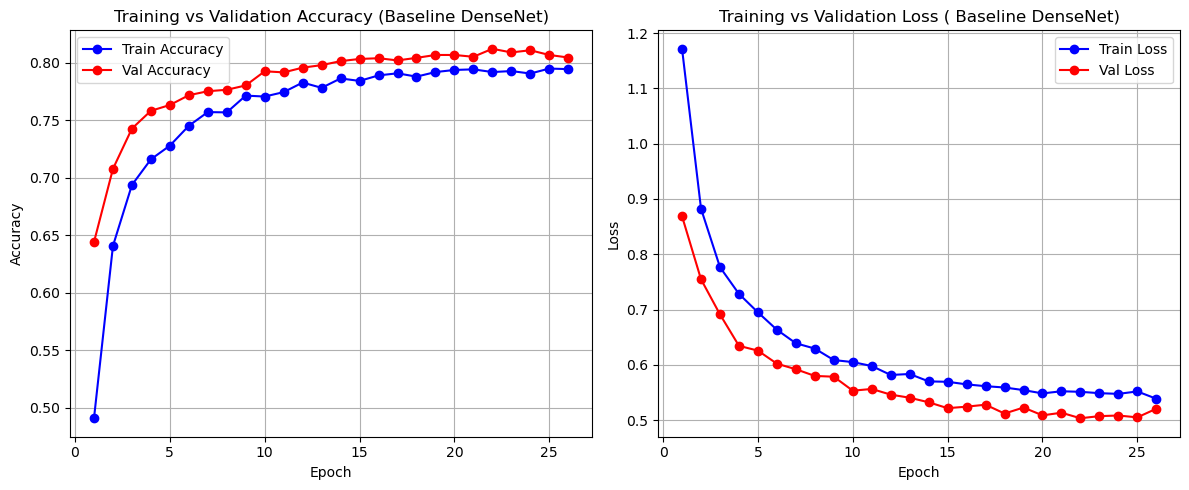

In [16]:
# Accuracy and Loss Curves
def plot_training_curves(history):

    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, history.history["accuracy"], 'b-o', label="Train Accuracy")
    plt.plot(epochs, history.history["val_accuracy"], 'r-o', label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Baseline DenseNet)")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, history.history["loss"], 'b-o', label="Train Loss")
    plt.plot(epochs, history.history["val_loss"], 'r-o', label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss ( Baseline DenseNet)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

In [17]:
# Classification Report
print("Classification Report: Baseline DenseNet")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report: Baseline DenseNet
                 precision    recall  f1-score   support

          COVID       0.83      0.57      0.68       542
   Lung_Opacity       0.83      0.76      0.79       902
         Normal       0.79      0.95      0.86      1529
Viral_Pneumonia       0.99      0.73      0.84       202

       accuracy                           0.82      3175
      macro avg       0.86      0.75      0.79      3175
   weighted avg       0.82      0.82      0.81      3175



In [18]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 309   70  162    1]
 [  43  684  175    0]
 [  19   62 1448    0]
 [   2    5   48  147]]


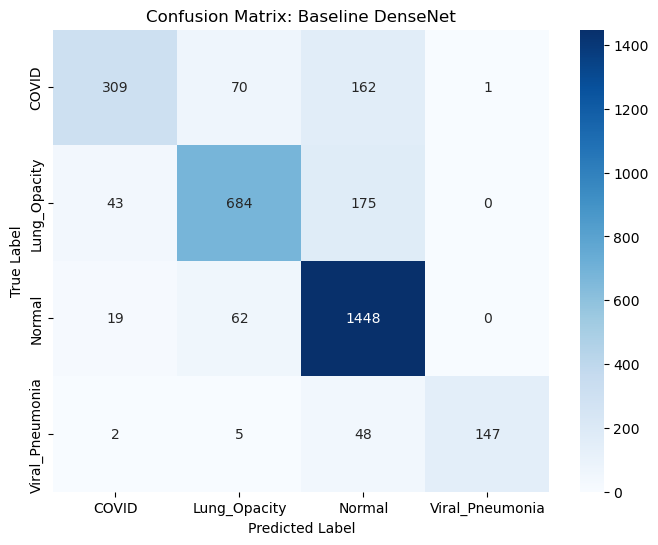

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Baseline DenseNet")
plt.show()

In [20]:
# RoC-AuC Score
y_true_oh = label_binarize(y_true, classes=range(NUM_CLASSES))
print("Macro AUC:", roc_auc_score(y_true_oh, probs, average="macro", multi_class="ovr"))

Macro AUC: 0.9472451152975392


In [21]:
# Binarize labels for multiclass ROC
num_classes = probs.shape[1]

y_true_bin = label_binarize(
    y_true,
    classes=range(num_classes)
)

In [22]:
# Compute ROC & AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [23]:
# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)

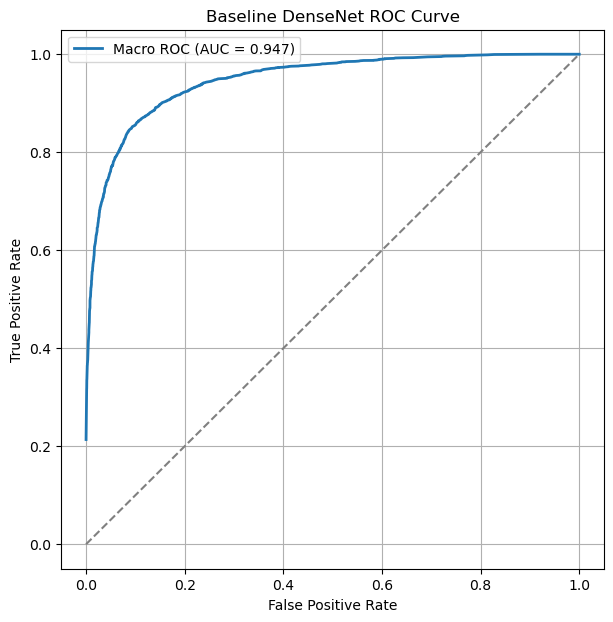

In [24]:
# Plot ROC curve
plt.figure(figsize=(7,7))
plt.plot(all_fpr, mean_tpr,
         label=f"Macro ROC (AUC = {macro_auc:.3f})",
         linewidth=2)

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline DenseNet ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Fine-Tuning Baseline Model

In [26]:
# Unfreeze Last 40 Layers

for layer in baseline_model.layers[-40:]:
    layer.trainable = True

for layer in baseline_model.layers[:-40]:
    layer.trainable = False

In [27]:
# Recompile

baseline_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
# Retrain
history_finetune = baseline_model.fit(
    train_ds_base,
    validation_data=val_ds_base,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True,
            mode="max"
        )
    ]
)

Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1388s 3s/step - accuracy: 0.6654 - loss: 1.0009 - val_accuracy: 0.8104 - val_loss: 0.5186
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1365s 3s/step - accuracy: 0.7714 - loss: 0.6436 - val_accuracy: 0.8233 - val_loss: 0.4816
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1359s 3s/step - accuracy: 0.7890 - loss: 0.6007 - val_accuracy: 0.8312 - val_loss: 0.4611
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1350s 3s/step - accuracy: 0.7914 - loss: 0.5759 - val_accuracy: 0.8356 - val_loss: 0.4460
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1349s 3s/step - accuracy: 0.8030 - loss: 0.5484 - val_accuracy: 0.8419 - val_loss: 0.4337
Epoch 6/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1328s 3s/step - accuracy: 0.8070 - loss: 0.5324 - val_accuracy: 0.8450 - val_loss: 0.4222
Epoch 7/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1307s 3s/step - accuracy: 0.8107 - loss: 0.5202 - val_accuracy: 0.8532 - val_loss: 0.4071
Epoch 8/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1307s 3s/step - accuracy: 0.8163 - loss: 0.5088 - 

# Evaluation

In [31]:
import numpy as np

# Get predicted probabilities
probs = baseline_model.predict(test_ds_base)

# Predicted class index
y_pred = np.argmax(probs, axis=1)

# True labels
y_true = np.concatenate(
    [labels.numpy().argmax(axis=1) for _, labels in test_ds_base],
    axis=0
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step


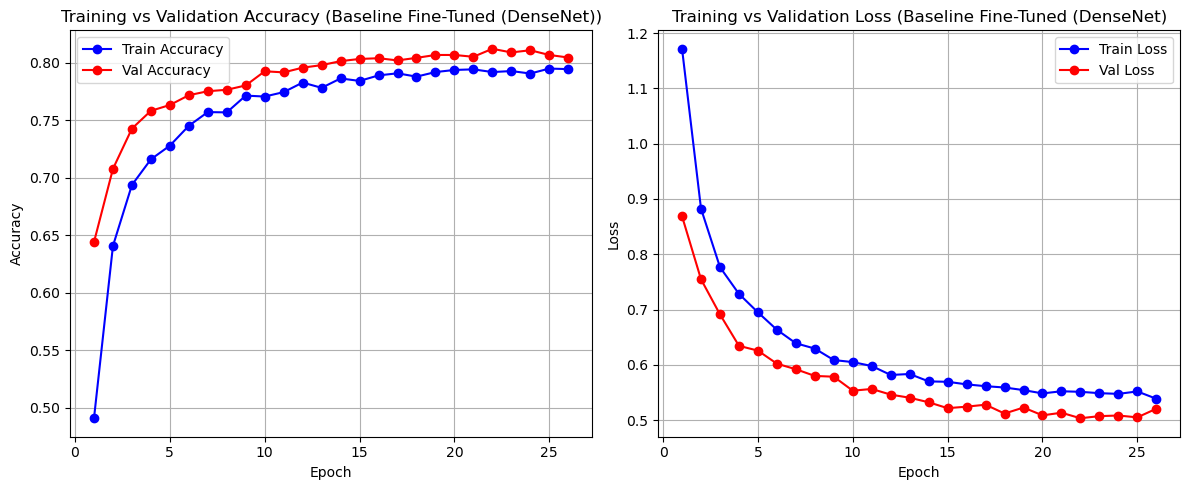

In [32]:
# Accuracy and Loss Curves

def plot_training_curves(history_finetune):

    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, history.history["accuracy"], 'b-o', label="Train Accuracy")
    plt.plot(epochs, history.history["val_accuracy"], 'r-o', label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Baseline Fine-Tuned (DenseNet))")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, history.history["loss"], 'b-o', label="Train Loss")
    plt.plot(epochs, history.history["val_loss"], 'r-o', label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss (Baseline Fine-Tuned (DenseNet)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_training_curves(history)

In [33]:
# Classification Report
print("Classification Report: Baseline Fine-Tuned (DenseNet)")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report: Baseline Fine-Tuned (DenseNet)
                 precision    recall  f1-score   support

          COVID       0.90      0.82      0.86       542
   Lung_Opacity       0.90      0.82      0.86       902
         Normal       0.87      0.96      0.91      1529
Viral_Pneumonia       0.99      0.83      0.90       202

       accuracy                           0.89      3175
      macro avg       0.92      0.86      0.88      3175
   weighted avg       0.89      0.89      0.89      3175



In [34]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 446   33   62    1]
 [  30  743  128    1]
 [  17   41 1471    0]
 [   0    5   30  167]]


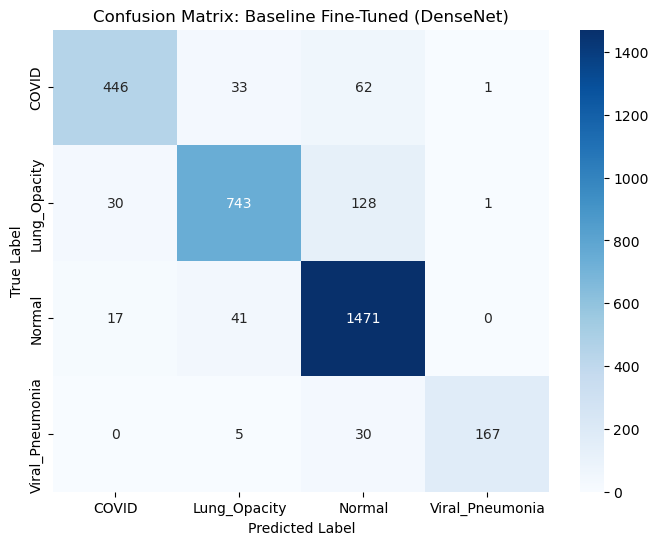

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Baseline Fine-Tuned (DenseNet)")
plt.show()

In [36]:
# RoC-AuC Score
y_true_oh = label_binarize(y_true, classes=range(NUM_CLASSES))
print("Macro AUC:", roc_auc_score(y_true_oh, probs, average="macro", multi_class="ovr"))

Macro AUC: 0.9795252536149349


In [37]:
# Binarize labels for multiclass ROC
num_classes = probs.shape[1]

y_true_bin = label_binarize(
    y_true,
    classes=range(num_classes)
)

In [38]:
# Compute ROC & AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [39]:
# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)


In [40]:
print(probs.shape)
print(y_true.shape)


(3175, 4)
(3175,)


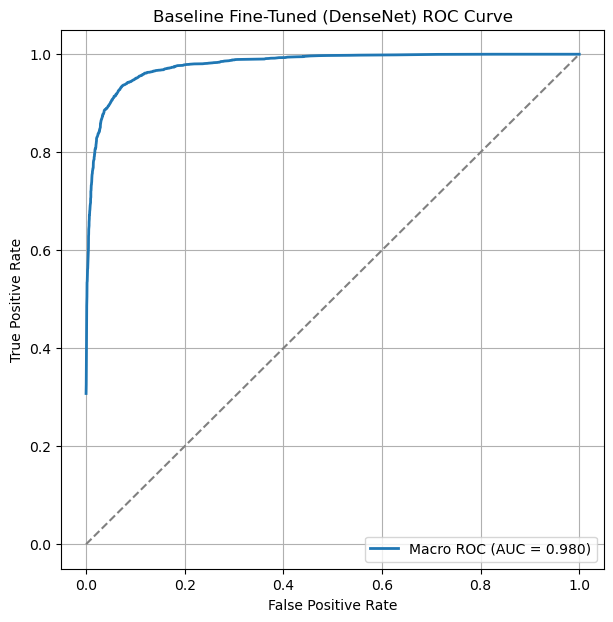

In [41]:
# Plot ROC curve
plt.figure(figsize=(7,7))
plt.plot(all_fpr, mean_tpr,
         label=f"Macro ROC (AUC = {macro_auc:.3f})",
         linewidth=2)

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Fine-Tuned (DenseNet) ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
# Create folder to save weights
base_dir = r"C:\Users\amysh\Desktop\AI_Project\DenseNet"
checkpoint_dir = os.path.join(base_dir, "checkpoints")

os.makedirs(checkpoint_dir, exist_ok=True)

print("Checkpoint folder created at:", checkpoint_dir)

Checkpoint folder created at: C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints


In [43]:
# Save baseline weights in the folder

baseline_weights_path = os.path.join(
    checkpoint_dir,
    "densenet_baseline_finetuned.weights.h5"
)

baseline_model.save_weights(baseline_weights_path)

print("Weights saved at:", baseline_weights_path)

Weights saved at: C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\densenet_baseline_finetuned.weights.h5


# # Multi-Task with Segmentation

# STEP 1 — Multi-Task DenseNet Model

We build the multitask model on the best weights from the baseline fine-tuned DenseNet model. This allows us to determine whether improvements in the multitasking are significant or not. So, the best weights from the baseline fine-tuned model are saved and then loaded to continue with the multitasking.

In [13]:
# Define Multi-Task Loader
IMG_SIZE = (224,224)
BATCH_SIZE = 32

def load_image_mask(img_path, mask_path, label):

    # ---- IMAGE ----
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, 3, axis=-1)

    # ---- MASK ----
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, IMG_SIZE, method="nearest")
    mask = tf.cast(mask > 127, tf.float32)

    # ---- LABEL ----
    label = tf.one_hot(label, depth=NUM_CLASSES)

    return img, (label, mask)

In [14]:
# Define Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

def augment_image(img, targets):
    label, mask = targets
    img = data_augmentation(img, training=True)
    return img, (label, mask)

In [15]:
# Multi-Task Dataset

def make_multitask_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (X[:,0].tolist(), X[:,1].tolist(), y)
    )

    ds = ds.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2048, seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_multitask_dataset(X_train, y_train, training=True)
val_ds   = make_multitask_dataset(X_val,   y_val,   training=False)
test_ds  = make_multitask_dataset(X_test,  y_test,  training=False)

In [16]:
# Sanity Checks
for imgs, (labels, masks) in train_ds.take(1):
    print("Images:", imgs.shape)
    print("Labels:", labels.shape)
    print("Masks: ", masks.shape)

Images: (32, 224, 224, 3)
Labels: (32, 4)
Masks:  (32, 224, 224, 1)


# Define Multi-Task DenseNet

In [17]:
def build_multitask_densenet(img_shape=(224,224,3), num_classes=4):

    inputs = keras.Input(shape=img_shape)

    # Shared Encoder 
    backbone = keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    # Feature map from backbone
    x = backbone.output  # (7,7,1024)

    
    # CLASSIFICATION HEAD
    cls = layers.GlobalAveragePooling2D()(x)
    cls = layers.Dense(512, activation="relu")(cls)
    cls = layers.BatchNormalization()(cls)
    cls = layers.Dropout(0.30)(cls)
    cls_out = layers.Dense(
        num_classes,
        activation="softmax",
        name="classification"
    )(cls)


    # SEGMENTATION HEAD
    seg = layers.Conv2D(256, 3, padding="same", activation="relu")(x)

    # 7 → 14 → 28 → 56 → 112 → 224
    for f in [128, 64, 32, 16]:
        seg = layers.UpSampling2D(size=(2,2))(seg)
        seg = layers.Conv2D(f, 3, padding="same", activation="relu")(seg)

    seg = layers.UpSampling2D(size=(2,2))(seg)

    seg_out = layers.Conv2D(
        1, 1,
        activation="sigmoid",
        name="segmentation"
    )(seg)

    model = keras.Model(
        inputs=inputs,
        outputs={
            "classification": cls_out,
            "segmentation": seg_out
        },
        name="MultiTask_DenseNet"
    )

    return model, backbone

In [18]:
# Load Baseline Fine-Tuned Weights into Backbone

baseline_model = build_densenet_baseline(NUM_CLASSES)

baseline_model.load_weights(
    r"C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\densenet_baseline_finetuned.weights.h5", skip_mismatch=True
)

In [18]:
# Build Multi-Task DenseNet
multitask_model, backbone = build_multitask_densenet(
    img_shape=(224,224,3),
    num_classes=NUM_CLASSES
)

In [20]:
# Transfer weights into multitask backbone
baseline_weights = baseline_model.get_weights()

In [21]:
# Frozen Backbone
backbone.trainable = False

# Freeze ENTIRE DenseNet backbone

for layer in backbone.layers:
    layer.trainable = False

# Double check number of trainable layers
print("Backbone trainable:", backbone.trainable)
print("Trainable layers:", sum([l.trainable for l in backbone.layers]))

# Check first backbone weight (should NOT be random)
print("Backbone weight mean:",
      np.mean(backbone.get_weights()[0]))

multitask_model.summary()

Backbone trainable: False
Trainable layers: 0
Backbone weight mean: -0.0003748805


Model: "MultiTask_DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_4              │ (None, 230, 230, 3)       │               0 │ input_layer_4[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d_4[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_5              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_5[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 10,317,893 (39.36 MB)

 Trainable params: 3,279,365 (12.51 MB)

 Non-trainable params: 7,038,528 (26.85 MB)

# PHASE 1 — Multi-Task

# Train Phase 1

In [22]:
# Compile (Balanced Loss)

multitask_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss={
        "classification": "categorical_crossentropy",
        "segmentation": "binary_crossentropy"
    },
    loss_weights={
        "classification": 1.0,
        "segmentation": 0.1   # keep segmentation controlled
    },
    metrics={
        "classification": ["accuracy"]
    }
)

phase1_path = r"C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_best.weights.h5" # checkpoint to save best weights

history_phase1 = multitask_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            filepath=phase1_path,
            monitor="val_classification_accuracy",
            save_best_only=True,
            save_weights_only=True,
            mode="max",
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_classification_accuracy",
            patience=3,
            restore_best_weights=True,
            mode="max"
        )
    ]
)


Epoch 1/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - classification_accuracy: 0.6171 - classification_loss: 1.0533 - loss: 1.0862 - segmentation_loss: 0.3288   
Epoch 1: val_classification_accuracy improved from None to 0.81165, saving model to C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_best.weights.h5
463/463 ━━━━━━━━━━━━━━━━━━━━ 1782s 4s/step - classification_accuracy: 0.7087 - classification_loss: 0.8236 - loss: 0.8492 - segmentation_loss: 0.2562 - val_classification_accuracy: 0.8117 - val_classification_loss: 0.5399 - val_loss: 0.5529 - val_segmentation_loss: 0.1714
Epoch 2/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - classification_accuracy: 0.7874 - classification_loss: 0.6103 - loss: 0.6308 - segmentation_loss: 0.2056   
Epoch 2: val_classification_accuracy improved from 0.81165 to 0.82110, saving model to C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_best.weights.h5
463/463 ━━━━━━━━━━━━━━━━━━━━ 1523s 3s/step - classificatio

# Evaluation

In [23]:
# Get predictions

preds = multitask_model.predict(test_ds)

probs = preds["classification"]
y_pred = probs.argmax(axis=1)

y_true = np.concatenate(
    [y.numpy().argmax(axis=1) for _, (y, _) in test_ds],
    axis=0
)


100/100 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step


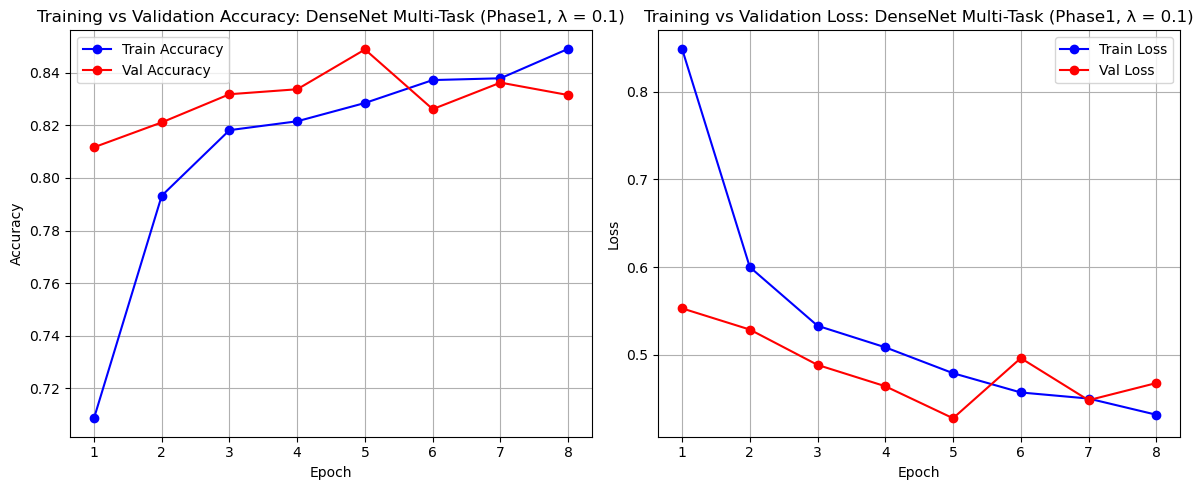

In [24]:
def plot_training_curves(history):

    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, history.history["classification_accuracy"],
             'b-o', label="Train Accuracy")
    plt.plot(epochs, history.history["val_classification_accuracy"],
             'r-o', label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy: DenseNet Multi-Task (Phase1, λ = 0.1)")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, history.history["loss"],
             'b-o', label="Train Loss")
    plt.plot(epochs, history.history["val_loss"],
             'r-o', label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss: DenseNet Multi-Task (Phase1, λ = 0.1)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_training_curves(history_phase1)

In [25]:
# Classification Report

from sklearn.metrics import classification_report
print("Classification Report: DenseNet Multi-Task (Phase1, λ = 0.1)")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report: DenseNet Multi-Task (Phase1, λ = 0.1)
                 precision    recall  f1-score   support

          COVID       0.84      0.67      0.75       542
   Lung_Opacity       0.80      0.82      0.81       902
         Normal       0.85      0.92      0.89      1529
Viral_Pneumonia       0.99      0.81      0.89       202

       accuracy                           0.84      3175
      macro avg       0.87      0.81      0.83      3175
   weighted avg       0.84      0.84      0.84      3175



In [26]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 364   80   97    1]
 [  42  743  117    0]
 [  28   93 1407    1]
 [   1   10   27  164]]


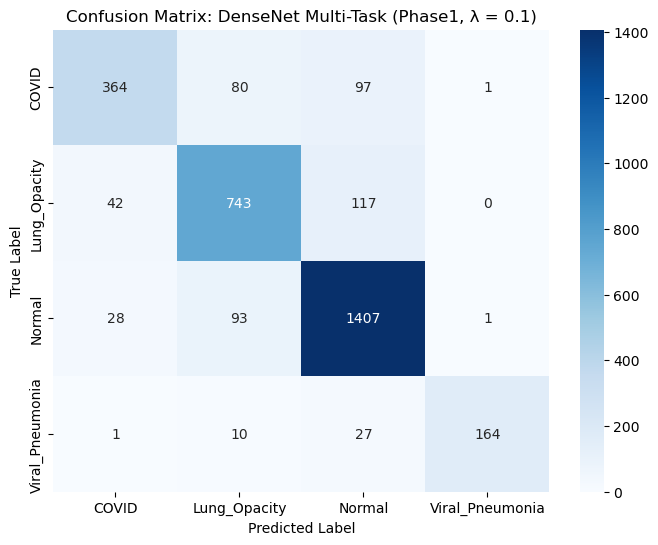

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: DenseNet Multi-Task (Phase1, λ = 0.1)")
plt.show()

In [28]:
# RoC-AuC Score
y_true_oh = label_binarize(y_true, classes=range(NUM_CLASSES))
print("Macro AUC:", roc_auc_score(y_true_oh, probs, average="macro", multi_class="ovr"))

Macro AUC: 0.9587341615656984


In [29]:
# Binarize labels for multiclass ROC
num_classes = probs.shape[1]

y_true_bin = label_binarize(
    y_true,
    classes=range(num_classes)
)

In [30]:
# Compute ROC & AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [31]:
# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)

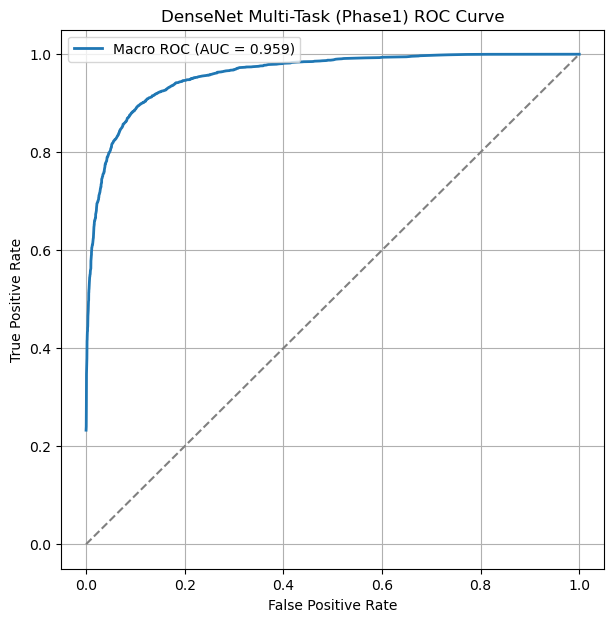

In [32]:
# Plot ROC curve
plt.figure(figsize=(7,7))
plt.plot(all_fpr, mean_tpr,
         label=f"Macro ROC (AUC = {macro_auc:.3f})",
         linewidth=2)

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DenseNet Multi-Task (Phase1) ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
# Load phase1 weights

#phase1_path = r"C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_best.weights.h5"

#multitask_model.load_weights(phase1_path)

In [92]:
# Load Phase1 Weights
multitask_model.load_weights(r"C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_best.weights.h5", skip_mismatch=True)

# PHASE 1.5 — FINE-TUNE (λ = 0.1)

In [33]:
# Unfreeze last N layers of DenseNet backbone
N = 40 

for layer in backbone.layers[:-N]:
    layer.trainable = False
for layer in backbone.layers[-N:]:
    layer.trainable = True

# (Optional but recommended) Keep BatchNorm frozen for stability
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Trainable backbone layers:",
      sum([l.trainable for l in backbone.layers]))

# Recompile (required after changing trainable flags)
multitask_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "classification": "categorical_crossentropy",
        "segmentation": "binary_crossentropy"
    },
    loss_weights={
        "classification": 1.0,
        "segmentation": 0.1
    },
    metrics={"classification": ["accuracy"]}
)

# 3) Train + save best weights
phase1_5_path = r"C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_5_best.weights.h5"

history_phase1_5 = multitask_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            filepath=phase1_5_path,
            monitor="val_classification_accuracy",
            save_best_only=True,
            save_weights_only=True,
            mode="max",
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_classification_accuracy",
            patience=3,
            restore_best_weights=True,
            mode="max"
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_classification_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1,
            mode="min"
        )
    ]
)

Trainable backbone layers: 29
Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - classification_accuracy: 0.8309 - classification_loss: 0.4663 - loss: 0.4833 - segmentation_loss: 0.1708   
Epoch 1: val_classification_accuracy improved from None to 0.84472, saving model to C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_5_best.weights.h5
463/463 ━━━━━━━━━━━━━━━━━━━━ 1702s 4s/step - classification_accuracy: 0.8412 - classification_loss: 0.4468 - loss: 0.4638 - segmentation_loss: 0.1702 - val_classification_accuracy: 0.8447 - val_classification_loss: 0.4338 - val_loss: 0.4442 - val_segmentation_loss: 0.1432 - learning_rate: 1.0000e-04
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - classification_accuracy: 0.8371 - classification_loss: 0.4357 - loss: 0.4525 - segmentation_loss: 0.1680   
Epoch 2: val_classification_accuracy did not improve from 0.84472
463/463 ━━━━━━━━━━━━━━━━━━━━ 1740s 4s/step - classification_accuracy: 0.8493 - classification_loss: 0.4065 

# Evaluation

In [34]:
# Get predictions

preds = multitask_model.predict(test_ds)

probs = preds["classification"]
y_pred = probs.argmax(axis=1)

y_true = np.concatenate(
    [y.numpy().argmax(axis=1) for _, (y, _) in test_ds],
    axis=0
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step


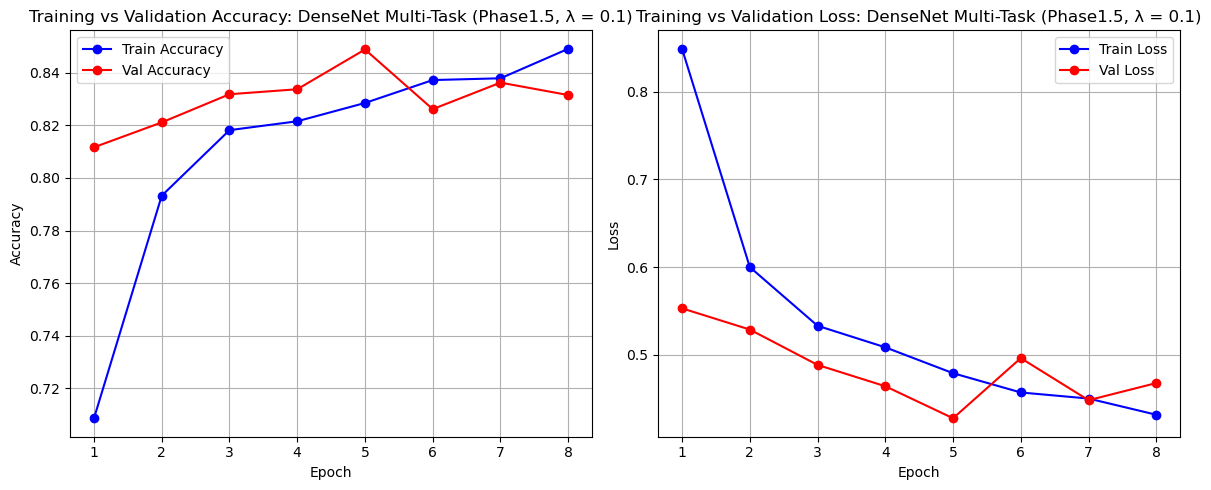

In [35]:
def plot_training_curves(history):

    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, history.history["classification_accuracy"],
             'b-o', label="Train Accuracy")
    plt.plot(epochs, history.history["val_classification_accuracy"],
             'r-o', label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy: DenseNet Multi-Task (Phase1.5, λ = 0.1)")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, history.history["loss"],
             'b-o', label="Train Loss")
    plt.plot(epochs, history.history["val_loss"],
             'r-o', label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss: DenseNet Multi-Task (Phase1.5, λ = 0.1)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_training_curves(history_phase1)

In [36]:
# Classification Report
print("Classification Report: DenseNet Multi-Task (Phase1.5, λ = 0.1)")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report: DenseNet Multi-Task (Phase1.5, λ = 0.1)
                 precision    recall  f1-score   support

          COVID       0.95      0.89      0.92       542
   Lung_Opacity       0.90      0.88      0.89       902
         Normal       0.91      0.95      0.93      1529
Viral_Pneumonia       0.99      0.91      0.95       202

       accuracy                           0.92      3175
      macro avg       0.94      0.91      0.92      3175
   weighted avg       0.92      0.92      0.92      3175



In [37]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 482   35   24    1]
 [   7  796   99    0]
 [  17   56 1455    1]
 [   1    2   16  183]]


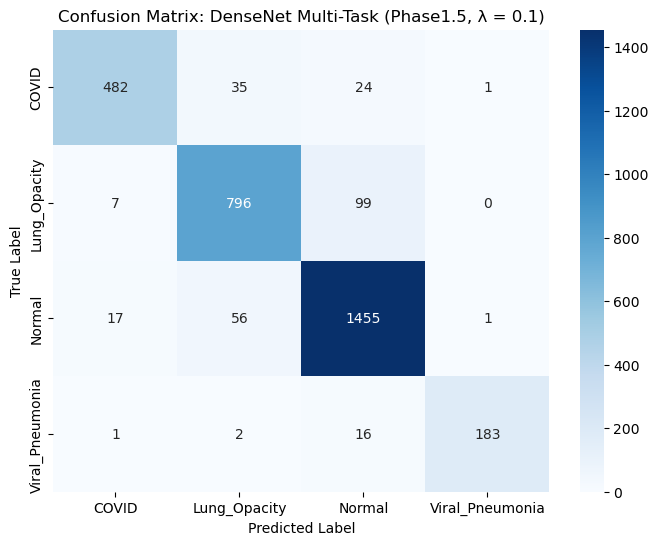

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: DenseNet Multi-Task (Phase1.5, λ = 0.1)")
plt.show()

In [39]:
# RoC-AuC Score
y_true_oh = label_binarize(y_true, classes=range(NUM_CLASSES))
print("Macro AUC:", roc_auc_score(y_true_oh, probs, average="macro", multi_class="ovr"))

Macro AUC: 0.9862838088096681


In [40]:
# Binarize labels for multiclass ROC
num_classes = probs.shape[1]

y_true_bin = label_binarize(
    y_true,
    classes=range(num_classes)
)

In [41]:
# Compute ROC & AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [42]:
# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)

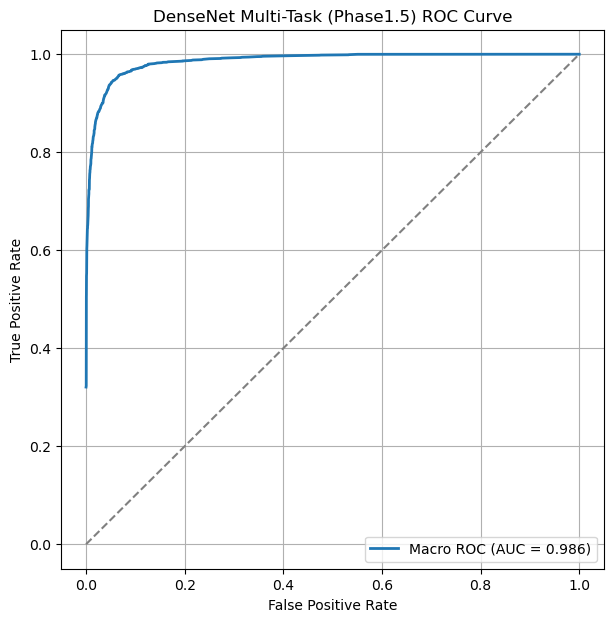

In [43]:
# Plot ROC curve
plt.figure(figsize=(7,7))
plt.plot(all_fpr, mean_tpr,
         label=f"Macro ROC (AUC = {macro_auc:.3f})",
         linewidth=2)

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DenseNet Multi-Task (Phase1.5) ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
phase1_5_path = r"C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_5_best.weights.h5"
multitask_model.load_weights(phase1_5_path)

# Dice and IoU

In [39]:
def dice_iou_per_batch(y_true, y_pred, eps=1e-7):
    # y_true, y_pred shape: (B, H, W, 1)
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)

    intersection = np.sum(y_true * y_pred, axis=(1, 2, 3))
    sum_true = np.sum(y_true, axis=(1, 2, 3))
    sum_pred = np.sum(y_pred, axis=(1, 2, 3))
    union = sum_true + sum_pred - intersection

    dice = (2.0 * intersection + eps) / (sum_true + sum_pred + eps)
    iou = (intersection + eps) / (union + eps)
    return dice, iou

dice_scores = []
iou_scores = []

threshold = 0.5

for imgs, (_, true_masks) in test_ds:
    preds = multitask_model.predict(imgs, verbose=0)
    pred_masks = preds["segmentation"]

    pred_masks_bin = (pred_masks >= threshold).astype(np.float32)
    true_masks_bin = (true_masks.numpy() >= 0.5).astype(np.float32)

    dice_b, iou_b = dice_iou_per_batch(true_masks_bin, pred_masks_bin)
    dice_scores.extend(dice_b.tolist())
    iou_scores.extend(iou_b.tolist())

dice_scores = np.array(dice_scores)
iou_scores = np.array(iou_scores)

print(f"Mean Dice: {dice_scores.mean():.4f}")
print(f"Mean IoU : {iou_scores.mean():.4f}")
print(f"Dice std : {dice_scores.std():.4f}")
print(f"IoU std  : {iou_scores.std():.4f}")

Mean Dice: 0.8865
Mean IoU : 0.8021
Dice std : 0.0698
IoU std  : 0.0963


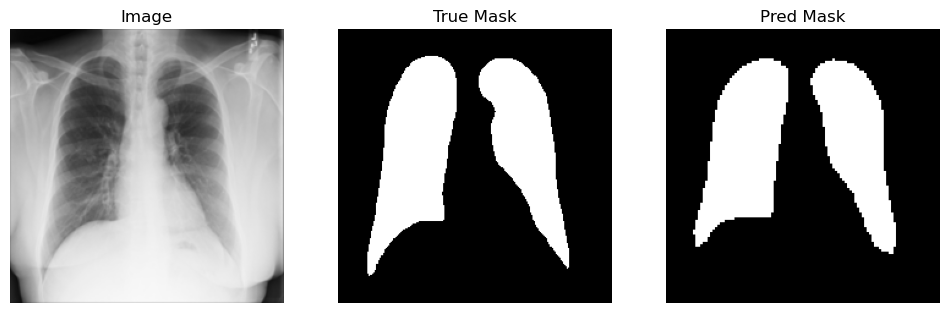

In [24]:
for imgs, (_, true_masks) in test_ds.take(1):
    preds = multitask_model.predict(imgs, verbose=0)
    pred_masks = preds["segmentation"]

    idx = 0
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(imgs[idx].numpy())
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(true_masks[idx].numpy().squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow((pred_masks[idx] >= 0.5).astype(np.float32).squeeze(), cmap="gray")
    plt.title("Pred Mask")
    plt.axis("off")

    plt.show()
    break

# Grad-CAM

In [31]:
for layer in multitask_model.layers:
    if layer.name == "relu":
        print("Found:", layer.name, layer.output.shape)

Found: relu (None, 7, 7, 1024)


In [ ]:
import cv2
import numpy as np

def overlay_gradcam(image, heatmap, alpha=0.4):
    """
    Overlay Grad-CAM heatmap on original image
    """

    # Ensure image is uint8
    if image.max() <= 1.0:
        image = (image * 255).astype(np.uint8)
    else:
        image = image.astype(np.uint8)

    # Convert heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Apply color map
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay
    overlay = cv2.addWeighted(image, 1 - alpha, heatmap, alpha, 0)

    return overlay

In [33]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output["classification"]
        ],
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy(), int(pred_index)

In [50]:
class_names = ["COVID", "Lung_Opacity", "Normal", "Viral_Pneumonia"]

C:\Users\amysh\AppData\Local\Temp\ipykernel_8856\1042907132.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


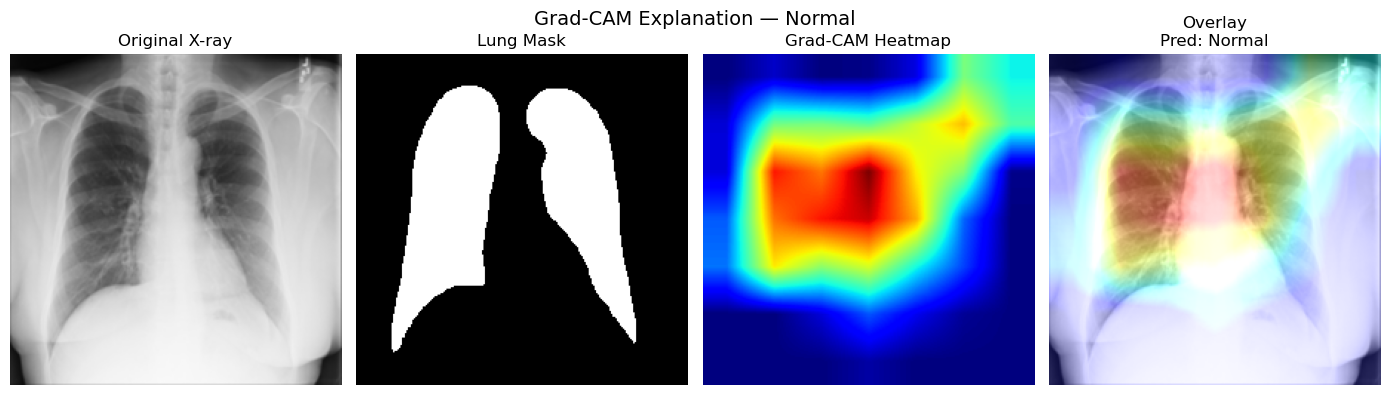

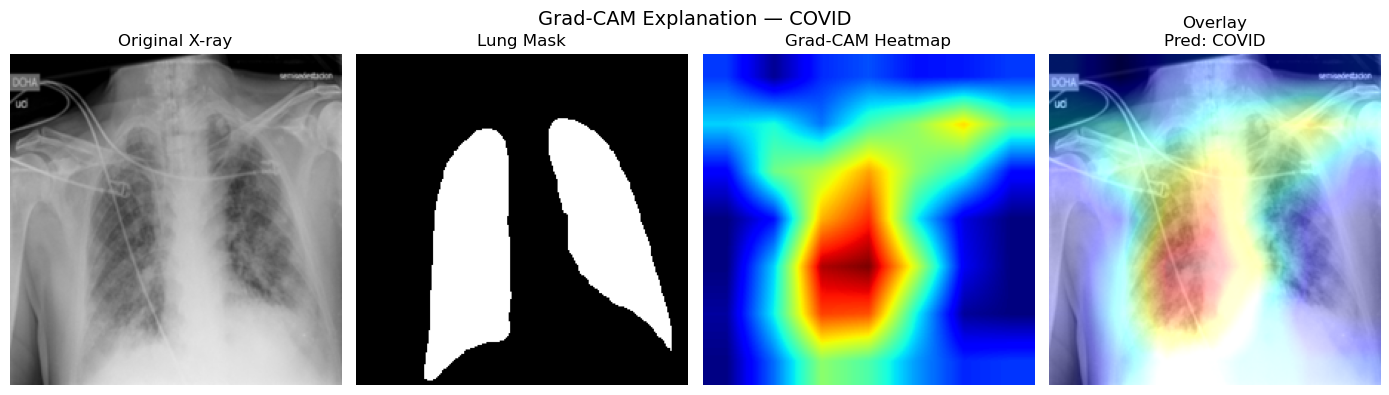

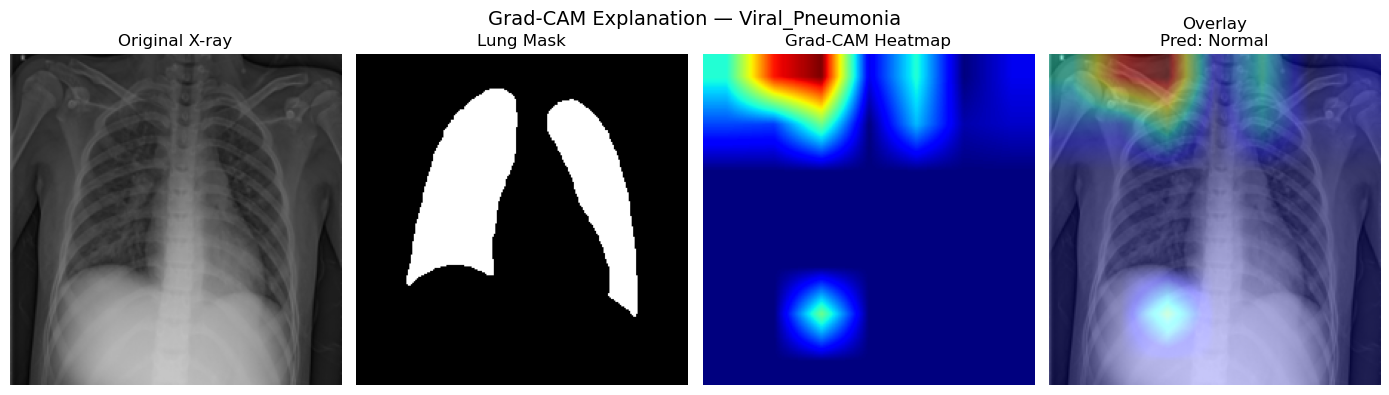

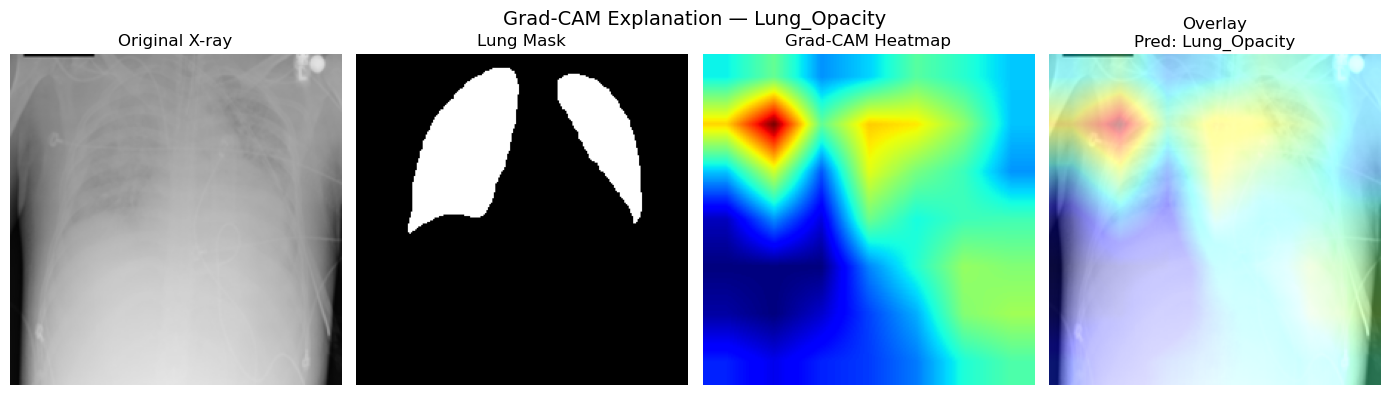

In [57]:
samples = {}

# Collect one image per class
for imgs, (labels, masks) in test_ds:

    for i in range(imgs.shape[0]):

        label = np.argmax(labels[i].numpy())

        if label not in samples:
            samples[label] = (imgs[i].numpy(), masks[i].numpy())

        if len(samples) == len(class_names):
            break

    if len(samples) == len(class_names):
        break


# Generate Grad-CAM for each class
for label, (img, true_mask) in samples.items():

    img_array = np.expand_dims(img, axis=0)

    heatmap, pred_class = make_gradcam_heatmap(
        img_array,
        multitask_model,
        last_conv_layer_name="relu"
    )

    # Smooth heatmap
    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        (224,224)
    ).numpy().squeeze()

    overlay_img = overlay_gradcam(img, heatmap)

    plt.figure(figsize=(14,4))

    # Original image
    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original X-ray")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(1,4,2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("Lung Mask")
    plt.axis("off")

    # Grad-CAM heatmap
    plt.subplot(1,4,3)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    # Overlay
    plt.subplot(1,4,4)
    plt.imshow(overlay_img)
    plt.title(f"Overlay\nPred: {class_names[pred_class]}")
    plt.axis("off")

    plt.suptitle(f"Grad-CAM Explanation — {class_names[label]}", fontsize=14)

    plt.tight_layout()

    # Save for report
    plt.savefig(f"gradcam_{class_names[label]}.png", dpi=300, bbox_inches="tight")

    plt.show()